# 📊 EDA - Análise Exploratória de Dados

## 🎯 Objetivo

Este projeto tem como objetivo prever o preço de fechamento de ações utilizando modelos de machine learning.

Antes do treinamento dos modelos, foi realizada uma análise exploratória dos dados (EDA) para entender o comportamento da série temporal.

## 📌 Ticker analisado
ITUB4.SA (Itaú Unibanco)

Este notebook apresenta uma **Análise Exploratória de Dados (EDA)** para o ativo **ITUB4.SA**, com foco em:

- comportamento do preço ao longo do tempo
- retornos diários
- volatilidade
- médias móveis
- correlação entre variáveis
- multicolinearidade

A ideia é documentar os principais padrões dos dados e gerar insights relevantes para o problema de previsão de preços.

# Importe de bibliotecas utilizadas

In [1]:
import sys

In [2]:
!{sys.executable} -m pip install yfinance pandas numpy matplotlib seaborn scikit-learn statsmodels plotly nbformat

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.figure_factory as ff

plt.style.use("ggplot")

""" 
statsmodels
É uma biblioteca de Python focada em estatística e econometria, oferecendo ferramentas para análise de dados, modelagem estatística 
e testes de hipóteses.
scikit-learn → foco em ML
statsmodels → foco em interpretação estatístic
Mede multicolinearidade
y=β0​+β1​X1​+β2​X2 
"""
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Coleta de dados

Faremos o download do dados via api yfinance , filtrando as ações do Itaú (ticker) entre 01/04/2025 a 01/04/2026 - Um ano.

In [4]:
ticker = "ITUB4.SA"

dados = yf.download(ticker, start="2025-04-01", end="2026-04-01")

dados.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA
Date,,,,,
2025-04-01,27.925247,28.165369,27.720699,27.916354,12749134
2025-04-02,27.934141,28.120903,27.729593,27.898567,12147820
2025-04-03,28.432171,28.636719,27.649553,27.702913,32876673
2025-04-04,27.694017,28.227620,27.489469,28.085327,32585286
2025-04-07,27.747379,28.120903,27.160415,27.480578,33261069


## Explicação das colunas do dataset (Yahoo Finance)

Os dados foram obtidos via `yfinance` e representam informações diárias do ativo **ITUB4.SA**.

---

### Date
Data do registro de negociação.

- Representa o dia em que ocorreram as transações
- Não inclui finais de semana ou feriados (mercado fechado)

---

### Open (Preço de abertura)
Preço da primeira negociação do ativo no início do pregão.

- Indica como o mercado começou o dia
- Pode ser influenciado por notícias ou eventos fora do horário de negociação

---

### Close (Preço de fechamento)
Preço da última negociação do ativo no dia.

- É o valor mais importante para análise
- Utilizado como variável alvo (target) no modelo de previsão

---

### High (Preço máximo)
Maior preço atingido pelo ativo durante o dia.

- Representa o pico de valorização
- Ajuda a entender a volatilidade

---

### Low (Preço mínimo)
Menor preço atingido pelo ativo durante o dia.

- Representa o ponto mais baixo do dia
- Importante para análise de risco

---

### Volume
Quantidade total de ações negociadas no dia.

- Indica o nível de atividade do mercado
- Volume alto → maior interesse/investidores
- Volume baixo → menor liquidez

---


## Preparação da base

Algumas versões do `yfinance` podem retornar colunas em formato `MultiIndex`.  
Aqui normalizamos as colunas e mantemos apenas os campos principais:

- Open
- High
- Low
- Close
- Volume

In [5]:
if isinstance(dados.columns, pd.MultiIndex):
    dados.columns = dados.columns.get_level_values(0)

dados = dados[["Open", "High", "Low", "Close", "Volume"]].copy()

for col in dados.columns:
    dados[col] = pd.to_numeric(dados[col], errors="coerce")

dados.dropna(inplace=True)

dados.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2025-04-01,27.916354,28.165369,27.720699,27.925247,12749134
2025-04-02,27.898567,28.120903,27.729593,27.934141,12147820
2025-04-03,27.702913,28.636719,27.649553,28.432171,32876673
2025-04-04,28.085327,28.227620,27.489469,27.694017,32585286
2025-04-07,27.480578,28.120903,27.160415,27.747379,33261069


## Criação de variáveis auxiliares

Para enriquecer a análise, serão criadas novas variáveis:

- **retorno**: variação percentual diária do preço de fechamento
- **volatilidade_20**: desvio padrão móvel dos retornos em 20 dias
- **mm_20**: média móvel de 20 dias
- **mm_50**: média móvel de 50 dias
- **amplitude**: diferença entre máxima e mínima do dia
- **variacao_dia**: diferença entre fechamento e abertura

In [6]:
dados["retorno"] = dados["Close"].pct_change()
dados["volatilidade_20"] = dados["retorno"].rolling(20).std()
dados["mm_20"] = dados["Close"].rolling(20).mean()
dados["mm_50"] = dados["Close"].rolling(50).mean()
dados["amplitude"] = dados["High"] - dados["Low"]
dados["variacao_dia"] = dados["Close"] - dados["Open"]

dados_eda = dados.dropna().copy()
dados_eda.head()

Price,Open,High,Low,Close,Volume,retorno,volatilidade_20,mm_20,mm_50,amplitude,variacao_dia
Date,,,,,,,,,,,
2025-06-12,32.425024,33.089879,32.398072,32.892220,22525482,0.007707,0.008429,33.205070,31.385043,0.691807,0.467195
2025-06-13,32.496902,32.658625,32.263307,32.496902,14821597,-0.012019,0.008619,33.143781,31.476476,0.395318,0.000000
2025-06-16,32.820342,33.440272,32.811358,33.089878,17874002,0.018247,0.009246,33.092121,31.579591,0.628914,0.269536
2025-06-17,33.233632,33.323477,33.035973,33.287540,20133513,0.005973,0.009396,33.052568,31.676698,0.287504,0.053909
2025-06-18,33.179720,33.314490,32.982064,33.089878,20285232,-0.005938,0.008369,33.037389,31.784616,0.332425,-0.089842


##  Visão geral estatística

A tabela abaixo resume métricas descritivas das variáveis numéricas.

In [7]:
pd.set_option("display.float_format", "{:,.4f}".format)

In [8]:
dados_eda.info()
dados_eda.describe().T

<class 'pandas.DataFrame'>
DatetimeIndex: 200 entries, 2025-06-12 to 2026-03-30
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Open             200 non-null    float64
 1   High             200 non-null    float64
 2   Low              200 non-null    float64
 3   Close            200 non-null    float64
 4   Volume           200 non-null    int64  
 5   retorno          200 non-null    float64
 6   volatilidade_20  200 non-null    float64
 7   mm_20            200 non-null    float64
 8   mm_50            200 non-null    float64
 9   amplitude        200 non-null    float64
 10  variacao_dia     200 non-null    float64
dtypes: float64(10), int64(1)
memory usage: 18.8 KB


,count,mean,std,min,25%,50%,75%,max
Price,,,,,,,,
Open,200.0000,37.3059,4.7083,30.9574,33.8116,35.8206,39.5493,48.6292
High,200.0000,37.6764,4.7969,31.3349,34.1216,36.0423,39.7996,49.2439
Low,200.0000,36.9603,4.5737,30.6967,33.5996,35.6004,39.2074,48.1831
Close,200.0000,37.3225,4.6993,30.9843,33.8437,35.8014,39.5642,48.9465
Volume,200.0000,"24,132,814.9500","10,118,217.6776","7,190,900.0000","17,019,385.5000","21,400,928.0000","29,347,738.5000","54,352,300.0000"
retorno,200.0000,0.0013,0.0142,-0.0462,-0.0074,0.0020,0.0110,0.0438
volatilidade_20,200.0000,0.0133,0.0035,0.0077,0.0105,0.0129,0.0160,0.0221
mm_20,200.0000,36.8796,4.5029,31.6293,33.0914,34.8316,38.7747,46.9073
mm_50,200.0000,35.8958,3.7122,31.3850,32.8876,34.6021,37.7969,44.3230


## Evolução do preço com médias móveis

As médias móveis ajudam a suavizar o ruído do preço e destacar tendências de curto e médio prazo.

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=dados_eda.index, y=dados_eda["Close"], mode="lines", name="Close"))

fig.add_trace(go.Scatter(x=dados_eda.index, y=dados_eda["mm_20"], mode="lines", name="MM 20"))

fig.add_trace(go.Scatter(x=dados_eda.index, y=dados_eda["mm_50"], mode="lines", name="MM 50"))

fig.update_layout(
    title=f"{ticker} - Preço de fechamento e médias móveis",
    xaxis_title="Data",
    yaxis_title="Preço",
    hovermode="x unified",  #  ESSA LINHA FAZ TUDO
)

fig.show()

dados_eda.groupby(dados_eda.index.to_period("M"))[["Close", "mm_20", "mm_50"]].mean()

Price,Close,mm_20,mm_50
Date,,,
2025-06,32.9469,33.0010,31.9269
2025-07,32.1134,32.6547,32.8000
2025-08,33.4000,32.3726,32.5665
2025-09,34.8301,34.3236,33.1708
2025-10,34.5029,34.5835,34.2706
2025-11,36.6880,35.7189,35.0582
2025-12,38.1750,37.4642,36.1289
2026-01,41.1035,39.1603,37.9193
2026-02,47.0732,44.5320,40.9834


### Insight

A média móvel de 20 dias acompanha mais rapidamente as mudanças de preço, enquanto a média móvel de 50 dias apresenta uma suavização maior.

Isso mostra que o ativo possui comportamento sequencial e reforça que o problema é adequado para modelagem de séries temporais.


## Retornos diários

O retorno diário mede a variação percentual do preço de fechamento de um dia para o outro.

- **retorno**: variação percentual diária do preço de fechamento (%)


In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=dados_eda.index, y=dados_eda["retorno"], mode="lines", name="Retorno"))

fig.update_layout(
    title=f"{ticker} - Retornos diários",
    xaxis_title="Data",
    yaxis_title="Retorno",
    hovermode="x unified",  #  permite ver valor ao passar mouse
)

fig.update_traces(hovertemplate="Data: %{x}<br>Retorno: %{y:.4f}<extra></extra>")

fig.show()

### Insight

Os retornos oscilam ao redor de zero, como esperado em ativos financeiros.

Picos positivos e negativos representam dias com maior impacto de mercado, indicando instabilidade pontual no comportamento do ativo.

## Distribuição dos retornos

A distribuição dos retornos permite verificar concentração dos valores, assimetria e presença de caudas longas.

- **retorno**: variação percentual diária do preço de fechamento (%)

In [11]:
# remover NaN
retornos = dados_eda["retorno"].dropna()

# histograma + curva KDE
fig = ff.create_distplot(
    [retornos], group_labels=["Retorno"], bin_size=0.002, show_rug=False  # ajuste fino
)

fig.update_layout(
    title=f"{ticker} - Distribuição dos retornos diários",
    xaxis_title="Retorno",
    yaxis_title="Densidade",
    hovermode="x unified",
)

fig.show()
retornos.head(10)

Date
2025-06-12    0.0077
2025-06-13   -0.0120
2025-06-16    0.0182
2025-06-17    0.0060
2025-06-18   -0.0059
2025-06-20   -0.0052
2025-06-23   -0.0022
2025-06-24    0.0189
2025-06-25   -0.0180
2025-06-26   -0.0074
Name: retorno, dtype: float64

### Insight

A maior parte dos retornos tende a se concentrar próxima de zero, mas com presença de extremos em alguns períodos.

Isso indica que o ativo pode apresentar eventos de maior risco, o que pode afetar o desempenho do modelo.

## Distribuição dos retornos e KDE

O histograma apresenta a frequência dos retornos diários, enquanto a curva KDE (Kernel Density Estimation) fornece uma estimativa suavizada da distribuição.

## Interpretação

- A maior concentração de retornos ocorre próxima de zero
- Isso indica que a maioria dos dias apresenta pequenas variações
- A presença de caudas na distribuição indica a ocorrência de eventos extremos (outliers)
- A distribuição é aproximadamente simétrica, mas não perfeitamente normal

## Conclusão

O ativo apresenta comportamento típico de séries financeiras, com retornos concentrados próximos de zero e presença de eventos extremos ocasionais.

## Volatilidade móvel

A volatilidade móvel de 20 dias é calculada com base no desvio padrão dos retornos e representa o nível de risco ao longo do tempo.

- **volatilidade_20**: desvio padrão móvel dos retornos em 20 dias

In [12]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=dados_eda.index,
        y=dados_eda["volatilidade_20"],
        mode="lines",
        name="Volatilidade 20",
        hovertemplate="Data: %{x}<br>Volatilidade: %{y:.4f}<extra></extra>",
    )
)

fig.update_layout(
    title=f"{ticker} - Volatilidade móvel de 20 dias",
    xaxis_title="Data",
    yaxis_title="Volatilidade",
    hovermode="x unified",
)

fig.show()

### Insight

Períodos de maior volatilidade indicam maior incerteza e risco no mercado.

Esse comportamento pode dificultar a previsão, pois a série se torna menos estável.

#### Análise da volatilidade móvel

A volatilidade móvel de 20 dias evidencia mudanças no nível de risco ao longo do tempo.

Observações:

- O período inicial apresenta aumento gradual da volatilidade
- Entre setembro e novembro há redução, indicando maior estabilidade
- Em dezembro ocorre um aumento abrupto, sugerindo evento de mercado relevante
- A partir de janeiro observa-se um regime de maior volatilidade

####  Interpretação

A volatilidade não é constante, apresentando diferentes regimes ao longo do tempo:

- períodos de baixa volatilidade (mercado mais previsível)
- períodos de alta volatilidade (mercado mais incerto)

####  Implicações

- Modelos podem ter desempenho diferente dependendo do regime
- Períodos de alta volatilidade tendem a aumentar o erro de previsão
- A volatilidade é uma variável importante para capturar risco e instabilidade

#### Conclusão

O ativo apresenta comportamento típico de séries financeiras, com volatilidade variável ao longo do tempo e presença de mudanças de regime.

## Correlação entre variáveis

A correlação mede a intensidade e a direção da relação linear entre duas variáveis.

Valores próximos de:

- **+1** → forte correlação positiva
- **0** → ausência de correlação linear
- **-1** → forte correlação negativa

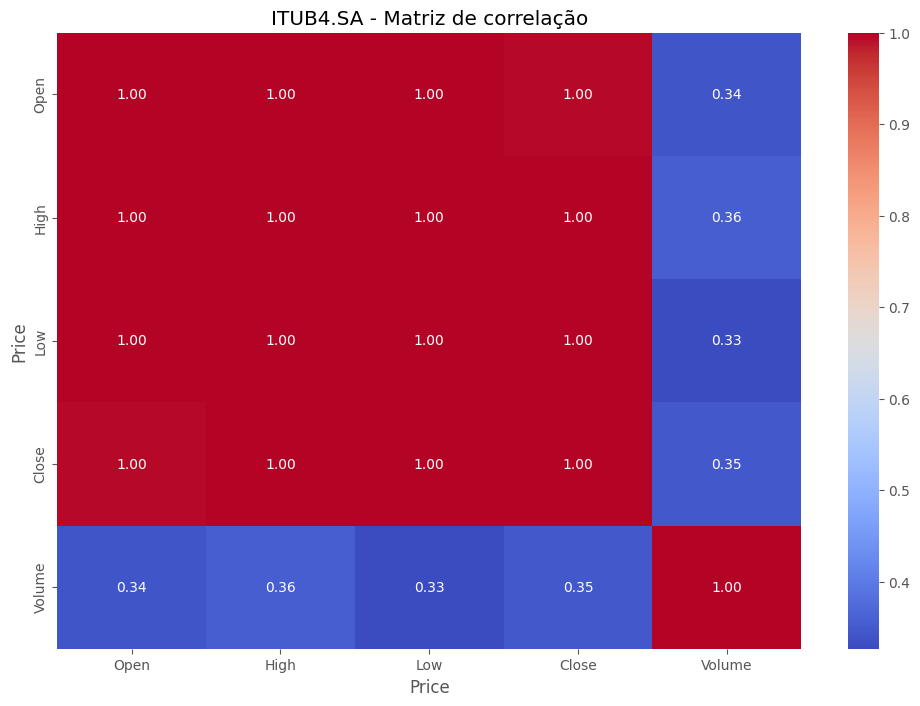

In [23]:
colunas_corr = ["Open", "High", "Low", "Close", "Volume"]

corr = dados[colunas_corr].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title(f"{ticker} - Matriz de correlação")
plt.show()

### Insight

As variáveis **Open, High, Low e Close** tendem a apresentar correlação muito forte entre si, pois representam o mesmo ativo no mesmo pregão, apenas em momentos diferentes do dia.

##  Covariância, correlação e multicolinearidade

### Covariância
A covariância mede como duas variáveis variam juntas.

- Covariância positiva: crescem juntas
- Covariância negativa: uma sobe enquanto a outra desce

### Correlação
A correlação é uma versão normalizada da covariância, facilitando a interpretação em uma escala de -1 a 1.

### Multicolinearidade
A multicolinearidade ocorre quando variáveis explicativas possuem correlação muito alta entre si.

Isso pode gerar:
- redundância de informação
- dificuldade de interpretação
- instabilidade em alguns modelos estatísticos

##  Medindo multicolinearidade com VIF

O **VIF (Variance Inflation Factor)** mede o quanto a variância de uma variável explicativa está inflada pela presença de outras variáveis correlacionadas.

### Regra prática
- **VIF = 1** → sem multicolinearidade
- **VIF > 5** → atenção
- **VIF > 10** → forte multicolinearidade

In [24]:
X_vif_preco = dados_eda[["Open", "High", "Low", "Close"]].copy()
X_vif_preco = add_constant(X_vif_preco)

vif_preco = pd.DataFrame()
vif_preco["variavel"] = X_vif_preco.columns
vif_preco["VIF"] = [
    variance_inflation_factor(X_vif_preco.values, i) for i in range(X_vif_preco.shape[1])
]

vif_preco

,variavel,VIF
0,const,81.2917
1,Open,452.7765
2,High,820.9800
3,Low,656.8294
4,Close,605.3309


### Insight

É esperado que as variáveis de preço apresentem VIF muito elevado, pois são altamente correlacionadas entre si.

Isso confirma a existência de multicolinearidade no conjunto de variáveis ligadas ao preço.

## VIF com conjunto ampliado de variáveis

Agora avaliamos a multicolinearidade incluindo médias móveis, volume e amplitude.

- **retorno**: variação percentual diária do preço de fechamento
- **volatilidade_20**: desvio padrão móvel dos retornos em 20 dias
- **mm_20**: média móvel de 20 dias
- **mm_50**: média móvel de 50 dias
- **amplitude**: diferença entre máxima e mínima do dia
- **variacao_dia**: diferença entre fechamento e abertura

In [25]:
X_vif_full = dados_eda[
    ["Open", "High", "Low", "Close", "mm_20", "mm_50", "Volume", "amplitude"]
].copy()
X_vif_full = add_constant(X_vif_full)

vif_full = pd.DataFrame()
vif_full["variavel"] = X_vif_full.columns
vif_full["VIF"] = [
    variance_inflation_factor(X_vif_full.values, i) for i in range(X_vif_full.shape[1])
]

vif_full

/home/clavezzo/.local/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,variavel,VIF
0,const,144.7706
1,Open,477.5923
2,High,inf
3,Low,inf
4,Close,609.9199
5,mm_20,37.1865
6,mm_50,20.5239
7,Volume,1.7490
8,amplitude,inf


### Insight

#### Interpretação do VIF

Os resultados do VIF mostraram valores extremamente elevados para variáveis ligadas ao preço, como `Open`, `Close`, `High`, `Low`, `mm_20`, `mm_50` e `amplitude`.

Em alguns casos, o VIF foi infinito (`inf`), o que indica dependência linear quase perfeita ou perfeita entre variáveis explicativas.

Esse comportamento era esperado, pois:

- `Open`, `High`, `Low` e `Close` representam o mesmo ativo no mesmo pregão
- `mm_20` e `mm_50` são derivadas diretamente do preço de fechamento
- `amplitude` é calculada como `High - Low`, sendo uma combinação linear exata dessas variáveis

Por outro lado, a variável `Volume` apresentou VIF baixo, indicando menor redundância e maior potencial de complementaridade para o modelo.

#### Conclusão

Os resultados confirmam a presença de **forte multicolinearidade** no conjunto de variáveis de preço.  
Isso sugere que não é recomendável utilizar simultaneamente todas essas colunas no modelo, pois muitas carregam informação repetida.

# Como melhorar a demonstração

Para mostrar um cenário “melhor”, rode um VIF com variáveis menos redundantes:

In [17]:
X_vif_melhor = dados_eda[["Close", "Volume", "retorno", "volatilidade_20"]].copy()
X_vif_melhor = add_constant(X_vif_melhor)

vif_melhor = pd.DataFrame()
vif_melhor["variavel"] = X_vif_melhor.columns
vif_melhor["VIF"] = [
    variance_inflation_factor(X_vif_melhor.values, i) for i in range(X_vif_melhor.shape[1])
]

vif_melhor

,variavel,VIF
0,const,72.6906
1,Close,2.1508
2,Volume,1.3785
3,retorno,1.0602
4,volatilidade_20,2.0985


## O que é a variável `const`

A variável `const` representa o termo constante (intercepto) adicionado ao modelo.

Ela é incluída automaticamente pela função `add_constant` para permitir que a regressão linear calcule corretamente os coeficientes.

No contexto do cálculo do VIF, a variável `const` não deve ser interpretada, pois serve apenas como suporte matemático para o modelo.

Intercepto é o β0 logo  y=β0​+β1​X1​+β2​X2

β₁, β₂ = pesos das variáveis no modelo

dizem o quanto cada variável influencia o resultado
ficam ruins quando há multicolinearidade

Se você tivesse um modelo assim:

Close=β0​+β1​⋅Open+β2​⋅Volume

interpretação:

β₁ → impacto do preço de abertura no fechamento
β₂ → impacto do volume no fechamento

## Gráfico do VIF

In [29]:
# incluir retorno
X_vif = dados_eda[["Close", "Open", "mm_20", "mm_50", "Volume", "retorno"]].copy()

# remover NaN (IMPORTANTE por causa do retorno)
X_vif = X_vif.dropna()

# adicionar constante
X_vif = add_constant(X_vif)

# calcular VIF
vif = pd.DataFrame()
vif["variavel"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

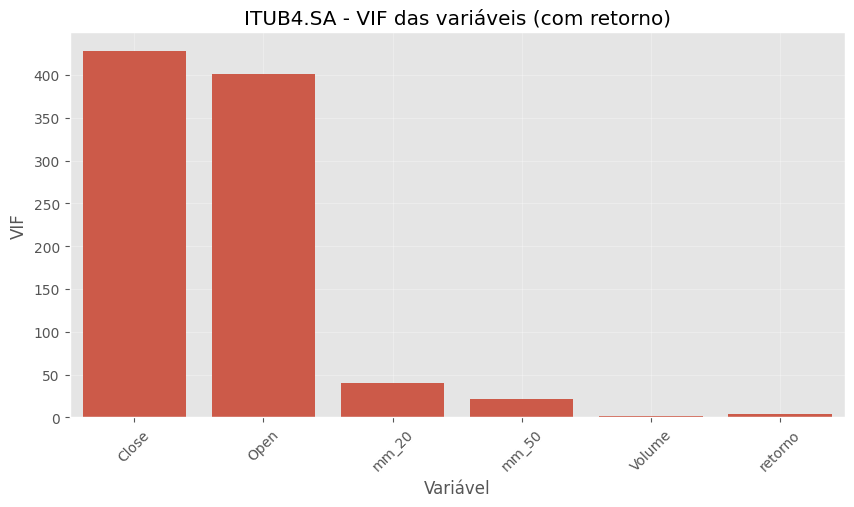

In [30]:
plt.figure(figsize=(10, 5))
sns.barplot(data=vif[vif["variavel"] != "const"], x="variavel", y="VIF")

plt.title(f"{ticker} - VIF das variáveis (com retorno)")
plt.xlabel("Variável")
plt.ylabel("VIF")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

### Insight

Variáveis com VIF muito alto indicam informação redundante.

No contexto deste projeto, isso sugere que nem todas as colunas de preço precisam ser usadas ao mesmo tempo, especialmente quando o objetivo é prever o comportamento do `Close`.

##  VIF incluindo retorno

A inclusão da variável retorno apresentou baixo VIF, indicando baixa multicolinearidade.

##  Interpretação

Diferente das variáveis de preço, o retorno representa a variação percentual do ativo, removendo a tendência acumulada.

Isso reduz a correlação com outras variáveis e torna o retorno uma feature mais informativa para modelagem.

##  Conclusão

A variável retorno apresenta maior independência e deve ser priorizada em relação às variáveis de preço, que apresentam alta redundância.

## Comparação entre preço e volatilidade normalizados

Este gráfico ajuda a comparar visualmente o comportamento do preço e da volatilidade em uma mesma escala.

In [32]:
# normalização
close_norm = dados_eda["Close"] / dados_eda["Close"].iloc[0]
vol_norm = dados_eda["volatilidade_20"] / dados_eda["volatilidade_20"].max()

fig = go.Figure()

fig.add_trace(go.Scatter(x=dados_eda.index, y=close_norm, mode="lines", name="Close normalizado"))

fig.add_trace(
    go.Scatter(x=dados_eda.index, y=vol_norm, mode="lines", name="Volatilidade 20 normalizada")
)

fig.update_layout(
    title=f"{ticker} - Preço normalizado vs volatilidade normalizada",
    xaxis_title="Data",
    yaxis_title="Escala normalizada",
    hovermode="x unified",  #  mostra os dois juntos
)

fig.update_traces(hovertemplate="Data: %{x}<br>Valor: %{y:.4f}<extra>%{fullData.name}</extra>")

fig.show()

### Insight

Picos de volatilidade costumam aparecer em momentos de maior instabilidade do ativo.

Essa informação pode ser útil para complementar a modelagem, principalmente em cenários onde apenas o preço de fechamento não explica toda a dinâmica do mercado.

## Preço normalizado vs volatilidade

A normalização permite comparar diretamente a evolução do preço e da volatilidade ao longo do tempo.

## Interpretação

- O período inicial apresenta crescimento com baixa volatilidade, indicando um movimento estável
- A partir de dezembro, observa-se aumento da volatilidade acompanhado de movimentos mais intensos no preço
- Em 2026, o ativo apresenta alta volatilidade, indicando maior risco e instabilidade

Azul sobe = preço sobe
Vermelho sobe = risco sobe

## Conclusão

O comportamento do ativo evidencia a existência de diferentes regimes de mercado:

- períodos de baixa volatilidade (mais previsíveis)
- períodos de alta volatilidade (mais incertos)

Isso reforça a importância de considerar o nível de risco na modelagem.

## 📦 Boxplot dos retornos

O boxplot permite identificar a dispersão dos retornos e a presença de outliers.

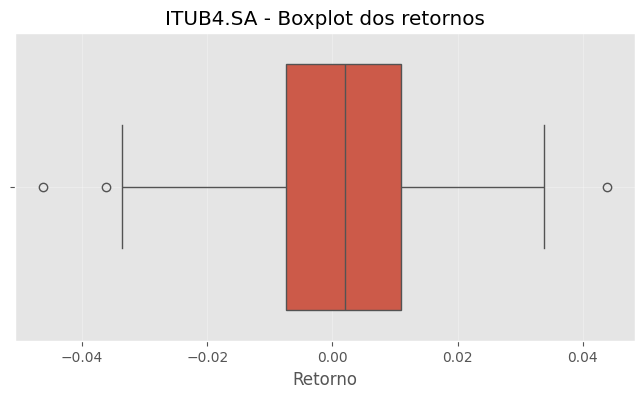

In [20]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=dados_eda["retorno"])
plt.title(f"{ticker} - Boxplot dos retornos")
plt.xlabel("Retorno")
plt.grid(True, alpha=0.3)
plt.show()

### Insight

Os outliers observados nos retornos representam dias com movimentos mais extremos de mercado.

Esses pontos podem impactar o treinamento dos modelos, especialmente em abordagens mais sensíveis a valores extremos.

#### Interpretação do boxplot dos retornos

O boxplot dos retornos diários permite visualizar a distribuição, dispersão e presença de valores extremos (outliers).

- **retorno**: variação percentual diária do preço de fechamento
- **volatilidade_20**: desvio padrão móvel dos retornos em 20 dias
- **mm_20**: média móvel de 20 dias
- **mm_50**: média móvel de 50 dias
- **amplitude**: diferença entre máxima e mínima do dia
- **variacao_dia**: diferença entre fechamento e abertura

A caixa vermelha → é o intervalo entre Q1 e Q3

A linha dentro da caixa → mediana

Os bigodes → linhas horizontais que saem da caixa Q1−1.5×IQReQ3+1.5×IQR <-> O que passar disso vira outlier (os pontinhos)

Os pontinhos fora → outliers

   o        |───────[  CAIXA  ]───────|        o o

 ← bigode esquerdo     bigode direito →

Estrutura do boxplot

Caixa (box)

Vai do Q1 (25%) ao Q3 (75%)

Representa onde está a maior parte dos dados

a maioria dos retornos está entre ~ -1% e +1%

Linha no meio

É a mediana

Observando o gráfico → está perto de 0

#### Interpretação:

o ativo não tem tendência diária forte (normal em mercado eficiente)

Bigodes (whiskers)

Mostram a variação "normal" dos dados

Aproximadamente até ±3%

⚫ Pontos fora (outliers)

 Esses pontos são MUITO importantes

Observando o gráfico:

~ -4% / -5%

~ +4% / +5%


#### Interpretação:

dias de alta volatilidade / eventos de mercado

Observações principais:

- A mediana está próxima de zero, indicando ausência de tendência diária consistente
- A maior parte dos retornos está concentrada em um intervalo estreito, aproximadamente entre -1% e +1%
- Os "bigodes" indicam a variação típica dos retornos, que se mantém dentro de uma faixa moderada
- A presença de outliers, tanto positivos quanto negativos, indica dias de maior volatilidade e eventos atípicos no mercado

#### Implicações

Os outliers representam movimentos abruptos de preço que podem impactar o desempenho do modelo, especialmente em abordagens mais sensíveis a 

extremos.

Isso reforça a importância de considerar variáveis como volatilidade no processo de modelagem.

## Boxplot dos retornos - Mensal

O boxplot permite identificar a dispersão dos retornos e a presença de outliers e principalmente se há sazonalidade.

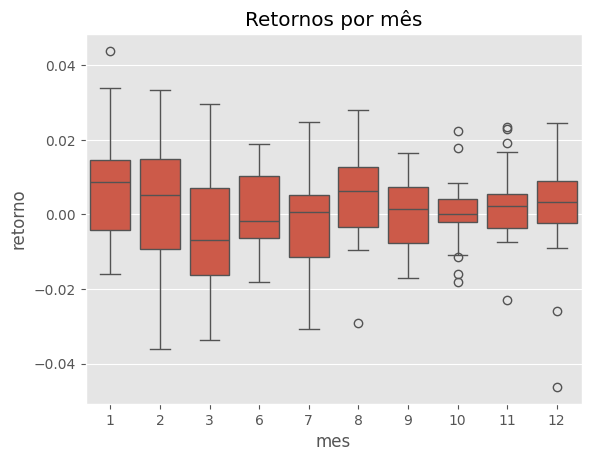

In [21]:
dados_eda["mes"] = dados_eda.index.month

sns.boxplot(x="mes", y="retorno", data=dados_eda)
plt.title("Retornos por mês")
plt.show()

### Insight

A análise dos retornos por mês não evidencia um padrão sazonal claro.

Observações:

- As medianas dos retornos permanecem próximas de zero na maioria dos meses
- A dispersão dos dados é relativamente semelhante entre os meses
- Os outliers estão distribuídos ao longo de diferentes períodos, sem concentração específica

#### Conclusão

Não há evidências de sazonalidade significativa nos retornos mensais do ativo.

O comportamento observado é mais consistente com um processo estocástico típico de mercados financeiros, onde as variações ocorrem de forma não determinística.

#### Implicação para o modelo

A ausência de sazonalidade sugere que:

- não há necessidade de incluir variáveis sazonais explícitas (como mês)
- o foco deve estar em dependência temporal e volatilidade

In [22]:
# calcular quartis
Q1 = dados_eda["retorno"].quantile(0.25)
Q3 = dados_eda["retorno"].quantile(0.75)

# IQR
IQR = Q3 - Q1

# limites
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# identificar outliers
outliers = dados_eda[(dados_eda["retorno"] < lower) | (dados_eda["retorno"] > upper)]

# calcular percentual
percentual_outliers = (len(outliers) / len(dados_eda)) * 100

print(f"Total de registros: {len(dados_eda)}")
print(f"Quantidade de outliers: {len(outliers)}")
print(f"Percentual de outliers: {percentual_outliers:.2f}%")

Total de registros: 200
Quantidade de outliers: 3
Percentual de outliers: 1.50%


### Insight

Os outliers foram identificados utilizando o método do intervalo interquartil (IQR), que define limites baseados na distribuição dos dados.

O percentual de outliers observado é consistente com o comportamento esperado de ativos financeiros, que apresentam eventos extremos ocasionais.

Esses valores refletem movimentos relevantes de mercado e não devem ser tratados como erro, mas sim como parte da dinâmica do ativo.

% outliers	Interpretação

< 1%	muito estável

1–5%	normal (mercado)

5–10%	alta volatilidade

> 10%	instável

# ✅ Conclusões Finais do EDA

A análise exploratória dos dados do ativo **ITUB4.SA** permitiu compreender a estrutura estatística da série temporal e identificar padrões relevantes para a modelagem.

---

## 📈 Comportamento do preço

- O ativo apresenta comportamento típico de série temporal financeira
- Observa-se variação ao longo do tempo, sem tendência linear simples
- As médias móveis evidenciam dependência temporal e ajudam a suavizar o ruído

---

## 📉 Retornos

- Os retornos diários estão concentrados próximos de zero
- Não há tendência consistente de alta ou baixa no curto prazo
- O comportamento é compatível com um processo estocástico

---

## ⚠️ Volatilidade

- Existem períodos de maior volatilidade ao longo da série
- A volatilidade não é constante, indicando mudanças no risco do ativo
- Esses períodos podem impactar a capacidade preditiva do modelo

---

## 📊 Outliers

A análise de outliers demonstra que o ativo apresenta comportamento consistente com mercados financeiros reais:

- baixa frequência de eventos extremos (**~2% dos dados**)
- presença de movimentos relevantes com alto impacto
- distribuição não normal, com caudas pesadas

Esses resultados reforçam a necessidade de modelos que considerem volatilidade e sejam robustos a eventos extremos.

#### 📈 Impacto na modelagem

A presença de outliers implica que:

- modelos podem apresentar maior erro em dias de alta volatilidade
- métricas como RMSE podem ser influenciadas por poucos pontos extremos
- abordagens mais robustas podem ser necessárias para capturar esse comportamento

---

## 🔗 Correlação entre variáveis

- As variáveis **Open, High, Low e Close** apresentam forte correlação
- As médias móveis também são altamente correlacionadas com o preço
- Isso indica redundância de informação entre as variáveis

---

## 📏 Multicolinearidade (VIF)

- O VIF apresentou valores elevados e até infinitos para variáveis de preço
- Isso confirma a presença de multicolinearidade extrema
- Variáveis derivadas (como médias móveis e amplitude) aumentam essa redundância

---

## 📅 Sazonalidade

- Não foi identificada sazonalidade significativa nos retornos mensais
- O comportamento do ativo é predominantemente não determinístico

---

## 🧠 Insights principais

- O preço carrega forte dependência temporal → adequado para modelos de séries temporais
- Variáveis de preço são altamente redundantes → cuidado na seleção de features
- Variáveis como **retorno, volatilidade e volume** agregam informação mais relevante
- A presença de outliers indica caudas pesadas (fat tails), típicas de mercados financeiros

---

## 🚀 Implicações para modelagem

Com base no EDA:

- Utilizar apenas o histórico de **Close** já captura grande parte da informação
- Evitar uso simultâneo de múltiplas variáveis altamente correlacionadas
- Incluir variáveis derivadas (retorno, volatilidade) pode melhorar o modelo
- Modelos devem ser robustos a outliers e mudanças de volatilidade
- Abordagens de séries temporais (como LSTM ou janelas temporais) são adequadas

---

## 📌 Conclusão geral

Os dados apresentam características clássicas de ativos financeiros:

- comportamento estocástico
- ausência de sazonalidade forte
- presença de eventos extremos
- alta correlação entre variáveis de preço

Essas evidências sustentam as escolhas de modelagem adotadas no projeto e reforçam a necessidade de abordagens que considerem dependência temporal e volatilidade.